### Aligning the mirrors M1 and M2 after the SLM

Because the beam falling on the SLM is ~9.6 to 9.7 mm in diameter, it s hard to resolve the 1st order from the specularly reflected 0th order.

Hence, I will separte the SLM sensor into two parts, a central part of dia 1-2 mm that will give the required 1st order carrier and the rest of the SLM sensor will have another phase that could be either all 0 (cpnstant phase) or a dumper blaze.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)


from slmsuite.hardware.slms.meadowlark import Meadowlark

In [2]:
# ============================================================
# Meadowlark paths
# ============================================================

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)


print("SDK exists :", SDK_PATH.exists())
print("LUT exists :", LUT_PATH.exists())


# ============================================================
# Initialize SLM
# ============================================================

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.759,
    verbose=True,
)


print("\n=== SLM READY ===")
print("Name       :", slm.name)
print("Shape      :", slm.shape)
print("Wavelength :", slm.wav_um, "um")
print("Pixel pitch:", slm.pitch_um, "um")

SDK exists : True
LUT exists : True
Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM READY ===
Name       : Meadowlark HDMI
Shape      : (1200, 1920)
Wavelength : 0.759 um
Pixel pitch: [8. 8.] um


### Simple zero phase to the entire SLM to spot the zeroth

In [3]:
slm.set_phase(None, settle=True)

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1200, 1920), dtype=uint8)

### Simple blaze to see if the SLM is responding

Sometimes the SLM can fuck up due to multiple reasons so it is better to check if your call is really doing something to the SLM.

In order to do this I check if a simple 1D blaze can be written on it!

In [4]:
import numpy as np
from slmsuite.holography.toolbox import convert_vector
from slmsuite.holography.toolbox.phase import blaze

vec = convert_vector(
    (10.0, 0.0),
    from_units="mrad",
    to_units="kxy",
    hardware=slm,
)

phase = blaze(
    grid=slm,
    vector=tuple(np.ravel(vec)),
)

slm.set_phase(phase, settle=True)

array([[ 33,   6, 235, ...,  19, 248, 221],
       [ 33,   6, 235, ...,  19, 248, 221],
       [ 33,   6, 235, ...,  19, 248, 221],
       ...,
       [ 33,   6, 235, ...,  19, 248, 221],
       [ 33,   6, 235, ...,  19, 248, 221],
       [ 33,   6, 235, ...,  19, 248, 221]],
      shape=(1200, 1920), dtype=uint8)

### Small alignment beam

Now as a next step I will just see if the central thing blaze and the exterior dump blaze generates the required pattern. Just on the python side.

Then as a next step I will write this on the SLM.

=== Alignment mask ===
SLM shape              : (1200, 1920)
Patch diameter         : 1 mm
Patch diameter         : 125.0 pixels
Useful carrier period  : 16 pixels
Dump period            : 3 pixels
Phase range            : 0.1963495408493614 to 6.086835766330225 rad


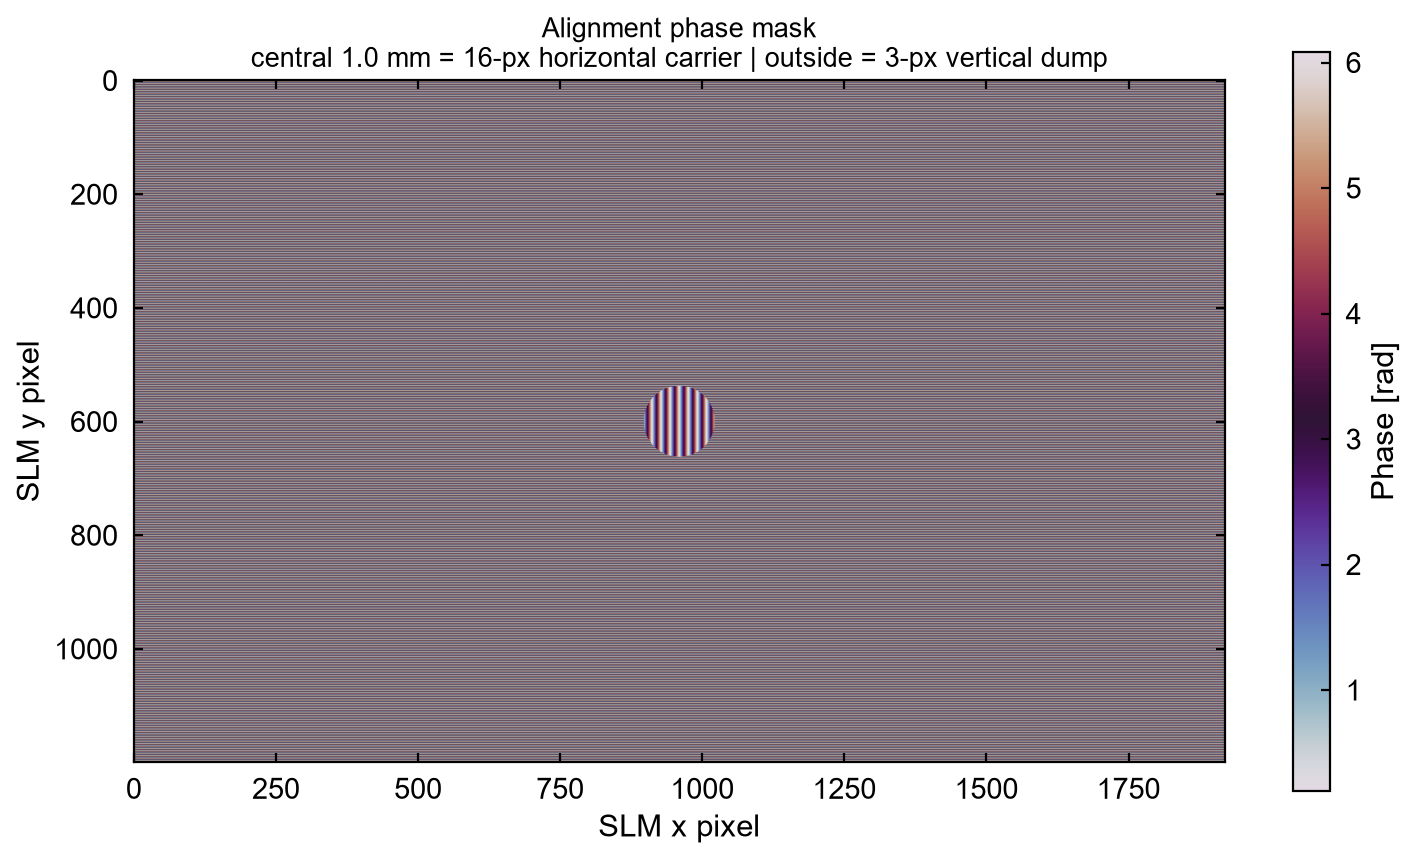

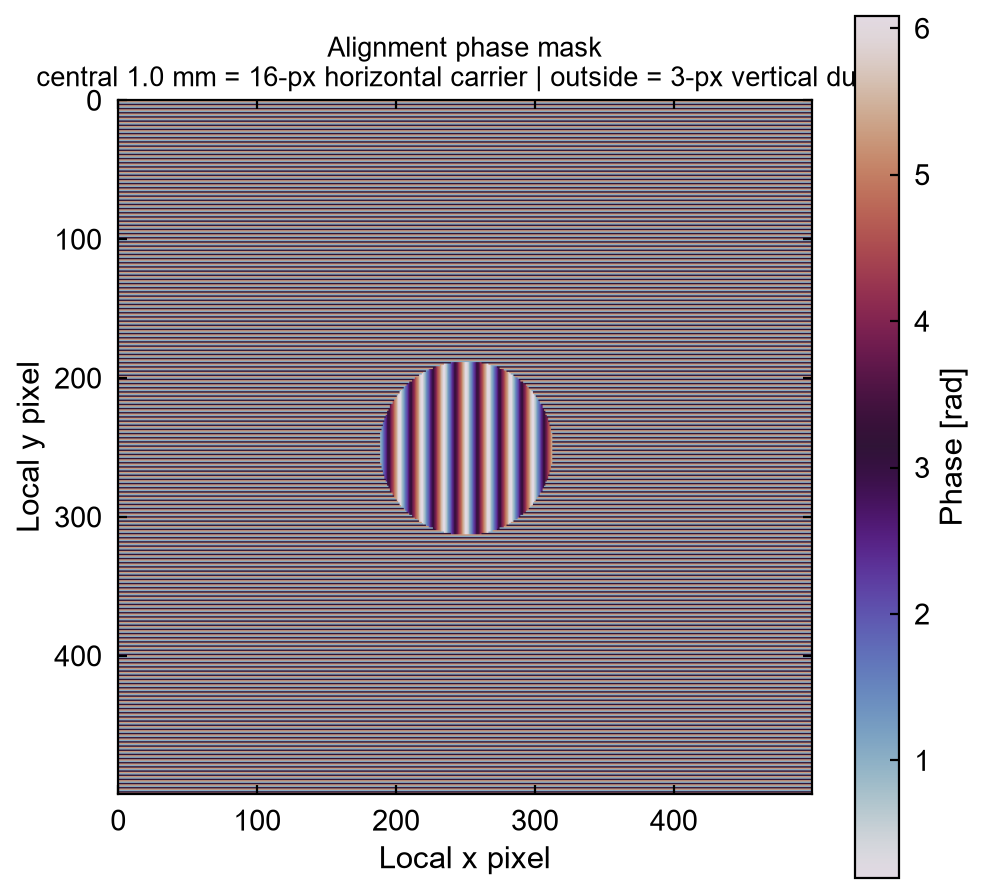

In [7]:
# ============================================================
# Diagnostic carrier pattern
# NO HARDWARE WRITE IN THIS CELL
# ============================================================

ny, nx = slm.shape
pixel_um = 8.0

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

PATCH_DIAMETER_MM = 1       # diagnostic patch diameter

CARRIER_PERIOD_PX = 16       # permanent useful carrier
DUMP_PERIOD_PX = 3           # temporary dump for rest of beam

# SLM center
cx = (nx - 1) / 2
cy = (ny - 1) / 2


# ============================================================
# Pixel coordinate arrays
# ============================================================

yy, xx = np.indices((ny, nx))

x = xx - cx
y = yy - cy


# ============================================================
# Circular diagnostic patch
# ============================================================

patch_radius_px = (
    PATCH_DIAMETER_MM * 1000
    / (2 * pixel_um)
)

patch_mask = (
    x**2 + y**2 <= patch_radius_px**2
)


# ============================================================
# Useful carrier:
# 16-pixel horizontal blaze
# ============================================================

phase_carrier = (
    2 * np.pi * x / CARRIER_PERIOD_PX
)


# ============================================================
# Dump carrier:
# 3-pixel vertical blaze
# ============================================================

phase_dump = (
    2 * np.pi * y / DUMP_PERIOD_PX
)


# ============================================================
# Combine
# ============================================================

phase_alignment = np.where(
    patch_mask,
    phase_carrier,
    phase_dump,
)

# Wrap into [0, 2pi)
phase_alignment = np.mod(
    phase_alignment,
    2 * np.pi,
)


# ============================================================
# Information
# ============================================================

print("=== Alignment mask ===")
print("SLM shape              :", phase_alignment.shape)
print("Patch diameter         :", PATCH_DIAMETER_MM, "mm")
print("Patch diameter         :", 2 * patch_radius_px, "pixels")
print("Useful carrier period  :", CARRIER_PERIOD_PX, "pixels")
print("Dump period            :", DUMP_PERIOD_PX, "pixels")
print("Phase range            :",
      phase_alignment.min(),
      "to",
      phase_alignment.max(),
      "rad")


# ============================================================
# Plot full SLM
# ============================================================

plt.figure(figsize=(11, 6))

plt.imshow(
    phase_alignment,
    origin="upper",
    cmap="twilight",
)

plt.colorbar(label="Phase [rad]")

plt.title(
    f"Alignment phase mask\n"
    f"central {PATCH_DIAMETER_MM:.1f} mm = "
    f"{CARRIER_PERIOD_PX}-px horizontal carrier | "
    f"outside = {DUMP_PERIOD_PX}-px vertical dump"
)

plt.xlabel("SLM x pixel")
plt.ylabel("SLM y pixel")

plt.show()


# ============================================================
# Zoom into central region
# ============================================================

zoom = 250

plt.figure(figsize=(7, 7))

plt.imshow(
    phase_alignment[
        int(cy - zoom):int(cy + zoom),
        int(cx - zoom):int(cx + zoom)
    ],
    origin="upper",
    cmap="twilight",
)

plt.colorbar(label="Phase [rad]")

plt.title(
    f"Alignment phase mask\n"
    f"central {PATCH_DIAMETER_MM:.1f} mm = "
    f"{CARRIER_PERIOD_PX}-px horizontal carrier | "
    f"outside = {DUMP_PERIOD_PX}-px vertical dump"
)

plt.xlabel("Local x pixel")
plt.ylabel("Local y pixel")

plt.show()

In [8]:
print("Writing diagnostic alignment mask to SLM...")

slm.set_phase(
    phase_alignment,
    settle=True,
)

print("Done.")

Writing diagnostic alignment mask to SLM...
Done.


Full-aperture 16-pixel carrier written.


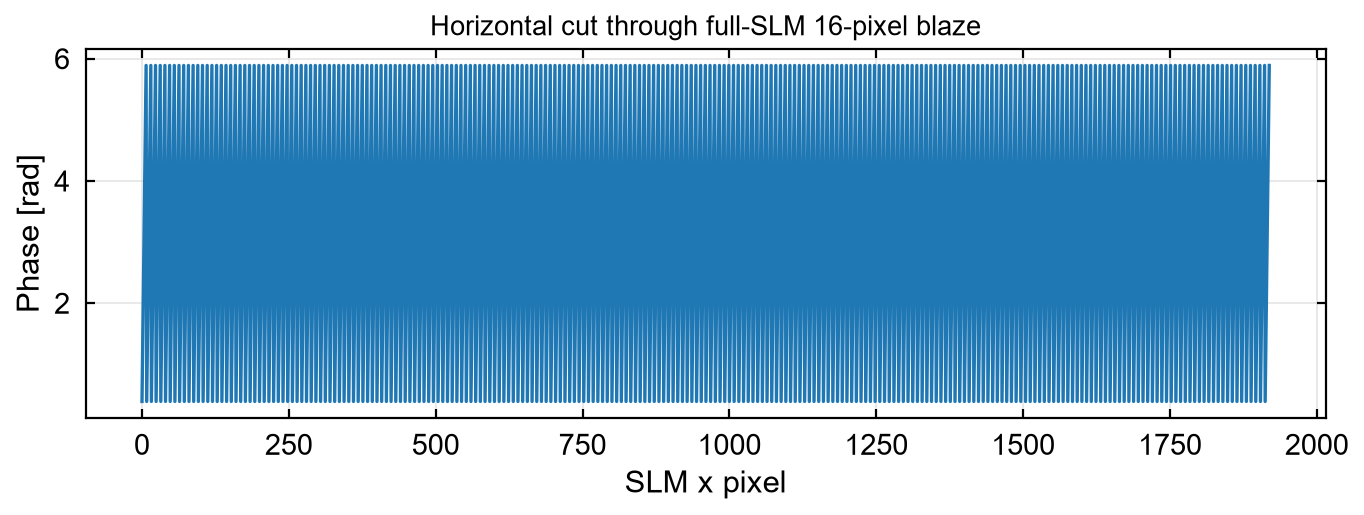

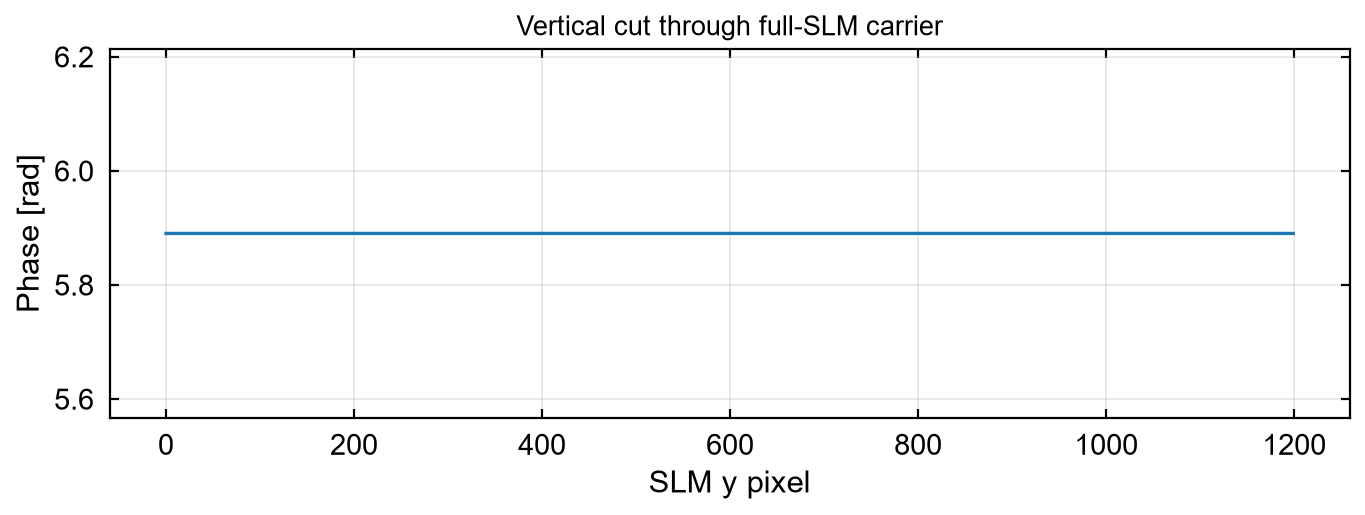

In [12]:
# ============================================================
# FULL-SLM 16-pixel carrier
# Same direction as the pilot beam
# ============================================================

CARRIER_PERIOD_PX = 8

phase_full_carrier = (
    2 * np.pi * x / CARRIER_PERIOD_PX
)

phase_full_carrier = np.mod(
    phase_full_carrier,
    2 * np.pi
)

# Write to SLM
slm.set_phase(
    phase_full_carrier,
    settle=True,
)

print("Full-aperture 16-pixel carrier written.")

plt.figure(figsize=(10, 3))

plt.plot(
    phase_full_carrier[int(cy), :]
)

plt.xlabel("SLM x pixel")
plt.ylabel("Phase [rad]")
plt.title("Horizontal cut through full-SLM 16-pixel blaze")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 3))

plt.plot(
    phase_full_carrier[:, int(cx)]
)

plt.xlabel("SLM y pixel")
plt.ylabel("Phase [rad]")
plt.title("Vertical cut through full-SLM carrier")
plt.grid(alpha=0.3)
plt.show()

Fourier-grid pixel size at camera:
  11.586 um
  4.827 camera pixels

16-pixel carrier:
  shift in knm       = 128.0
  shift at camera    = 1483.0 um
  shift on camera    = 617.9 pixels

Desired 5 um atomic spacing:
  desired camera spacing = 147.06 um
  desired camera spacing = 61.27 pixels
  ideal knm pitch        = 12.693

Using integer knm pitch = 13
  camera spacing = 150.62 um
  camera spacing = 62.76 pixels
  atomic spacing = 5.121 um


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]


Generated phase shape: (1200, 1920)
SLM shape            : (1200, 1920)


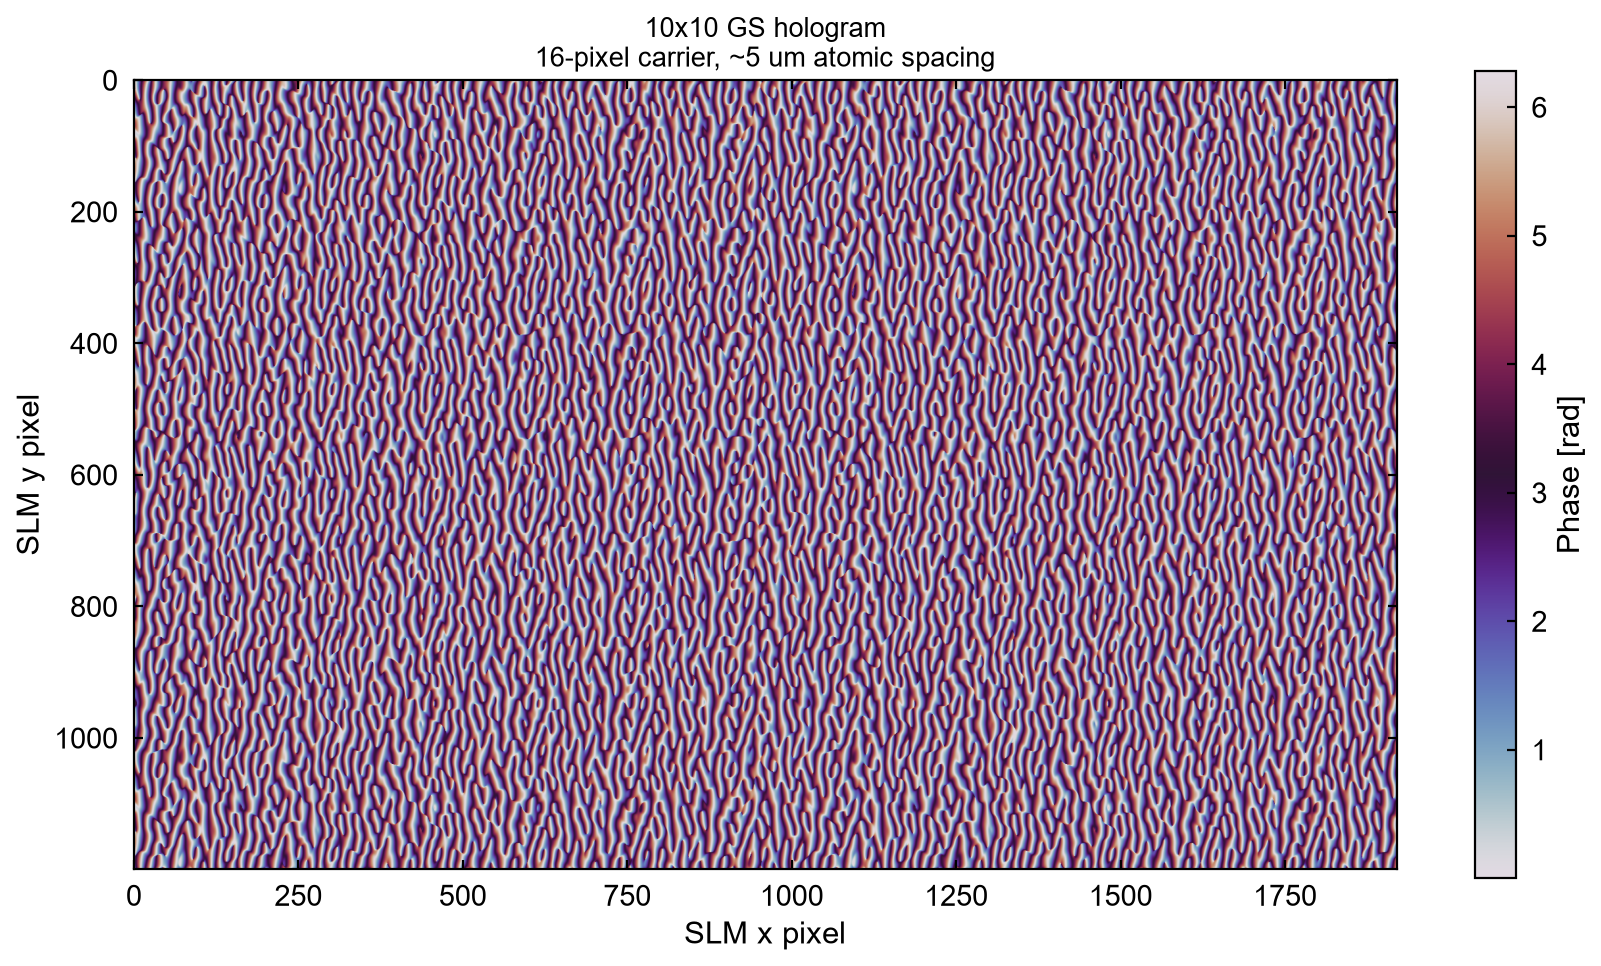


10x10 array written to SLM.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.holography.algorithms import SpotHologram


# ============================================================
# PARAMETERS
# ============================================================

wavelength_nm = 759.3
slm_pixel_um = 8.0

f1_mm = 250.0
f2_mm = 750.0
fobj_mm = 25.5          # approximate objective focal length

camera_pixel_um = 2.4

N_ARRAY = 10
CARRIER_PERIOD_PX = 16

GS_ITERS = 30


# ============================================================
# COMPUTATIONAL GRID
# ============================================================
#
# SLM is ~1200 x 1920.
# Use a square padded Fourier grid.
#
# This gives equal physical Fourier-pixel size in x and y.
# ============================================================

comp_shape = (2048, 2048)

Ny, Nx = comp_shape

cx_k = Nx / 2
cy_k = Ny / 2


# ============================================================
# PHYSICAL SIZE OF ONE knm PIXEL AT L1 FOCAL PLANE
# ============================================================

lambda_m = wavelength_nm * 1e-9
p_slm_m = slm_pixel_um * 1e-6
f1_m = f1_mm * 1e-3

dx_fourier_m = (
    f1_m * lambda_m
    / (Nx * p_slm_m)
)

dx_fourier_um = dx_fourier_m * 1e6

print("Fourier-grid pixel size at camera:")
print(f"  {dx_fourier_um:.3f} um")
print(f"  {dx_fourier_um / camera_pixel_um:.3f} camera pixels")


# ============================================================
# CARRIER CENTER
# ============================================================
#
# 16-pixel blaze:
#
# Fourier displacement = N / 16
#
# With N=2048:
#
# displacement = 128 knm pixels
# ============================================================

carrier_shift_knm = Nx / CARRIER_PERIOD_PX

array_center_knm = (
    cx_k + carrier_shift_knm,
    cy_k
)

carrier_shift_um = (
    carrier_shift_knm
    * dx_fourier_um
)

carrier_shift_camera_px = (
    carrier_shift_um
    / camera_pixel_um
)

print()
print("16-pixel carrier:")
print(f"  shift in knm       = {carrier_shift_knm:.1f}")
print(f"  shift at camera    = {carrier_shift_um:.1f} um")
print(f"  shift on camera    = {carrier_shift_camera_px:.1f} pixels")


# ============================================================
# DESIRED TWEEZER SPACING
# ============================================================
#
# At atoms we want 5 um.
#
# Camera-plane spacing:
#
# dx_camera = dx_atom * f2 / fobj
# ============================================================

atom_spacing_target_um = 5.0

camera_spacing_target_um = (
    atom_spacing_target_um
    * f2_mm
    / fobj_mm
)

camera_spacing_target_px = (
    camera_spacing_target_um
    / camera_pixel_um
)

knm_pitch_ideal = (
    camera_spacing_target_um
    / dx_fourier_um
)

print()
print("Desired 5 um atomic spacing:")
print(f"  desired camera spacing = {camera_spacing_target_um:.2f} um")
print(f"  desired camera spacing = {camera_spacing_target_px:.2f} pixels")
print(f"  ideal knm pitch        = {knm_pitch_ideal:.3f}")


# ============================================================
# USE INTEGER knm PITCH
# ============================================================
#
# SpotHologram ultimately puts targets on a discrete knm grid.
# Integer pitch avoids alternating 12/13-pixel spacings.
#
# 13 is very close to ideal.
# ============================================================

ARRAY_PITCH_KNM = 13

actual_camera_spacing_um = (
    ARRAY_PITCH_KNM
    * dx_fourier_um
)

actual_camera_spacing_px = (
    actual_camera_spacing_um
    / camera_pixel_um
)

actual_atom_spacing_um = (
    actual_camera_spacing_um
    * fobj_mm
    / f2_mm
)

print()
print("Using integer knm pitch =", ARRAY_PITCH_KNM)

print(f"  camera spacing = {actual_camera_spacing_um:.2f} um")
print(f"  camera spacing = {actual_camera_spacing_px:.2f} pixels")
print(f"  atomic spacing = {actual_atom_spacing_um:.3f} um")


# ============================================================
# CREATE 10 x 10 SPOT HOLOGRAM
# ============================================================

holo = SpotHologram.make_rectangular_array(
    shape=comp_shape,

    array_shape=(N_ARRAY, N_ARRAY),

    array_pitch=(
        ARRAY_PITCH_KNM,
        ARRAY_PITCH_KNM
    ),

    array_center=array_center_knm,

    basis="knm",

    # Physical SLM size is still the actual SLM.
    # Computational grid is larger only because of zero-padding.
    slm_shape=slm.shape,
)


# ============================================================
# RUN PLAIN GS
# ============================================================

holo.optimize(
    method="GS",
    maxiter=GS_ITERS,
)


# ============================================================
# GET PHASE
# ============================================================

phase_10x10 = holo.get_phase()

print()
print("Generated phase shape:", phase_10x10.shape)
print("SLM shape            :", slm.shape)


# ============================================================
# PLOT PHASE
# ============================================================

plt.figure(figsize=(11, 6))

plt.imshow(
    phase_10x10,
    origin="upper",
    cmap="twilight"
)

plt.colorbar(label="Phase [rad]")

plt.title(
    "10x10 GS hologram\n"
    "16-pixel carrier, ~5 um atomic spacing"
)

plt.xlabel("SLM x pixel")
plt.ylabel("SLM y pixel")

plt.tight_layout()
plt.show()


# ============================================================
# WRITE TO SLM
# ============================================================

slm.set_phase(
    phase_10x10,
    settle=True
)

print()
print("10x10 array written to SLM.")

### Projecting an array

I will use two arrays, 5x5 and 10x10 to see what chanege does the wavefront correction brings in.

Fourier-grid pixel size:
  11.586 um
  4.827 camera pixels

16-pixel carrier:
  shift in knm       = 128.0
  shift at camera    = 1483.0 um
  shift on camera    = 617.9 pixels

Array pitch:
  pitch in knm       = 13
  camera spacing     = 150.62 um
  camera spacing     = 62.76 px
  atomic spacing     = 5.121 um

Generating 5 x 5 array


  0%|          | 0/30 [00:00<?, ?it/s]


Generated phase shape : (1200, 1920)
Physical SLM shape    : (1200, 1920)
Saved phase as:
  baseline_5x5_GS_phase.npy


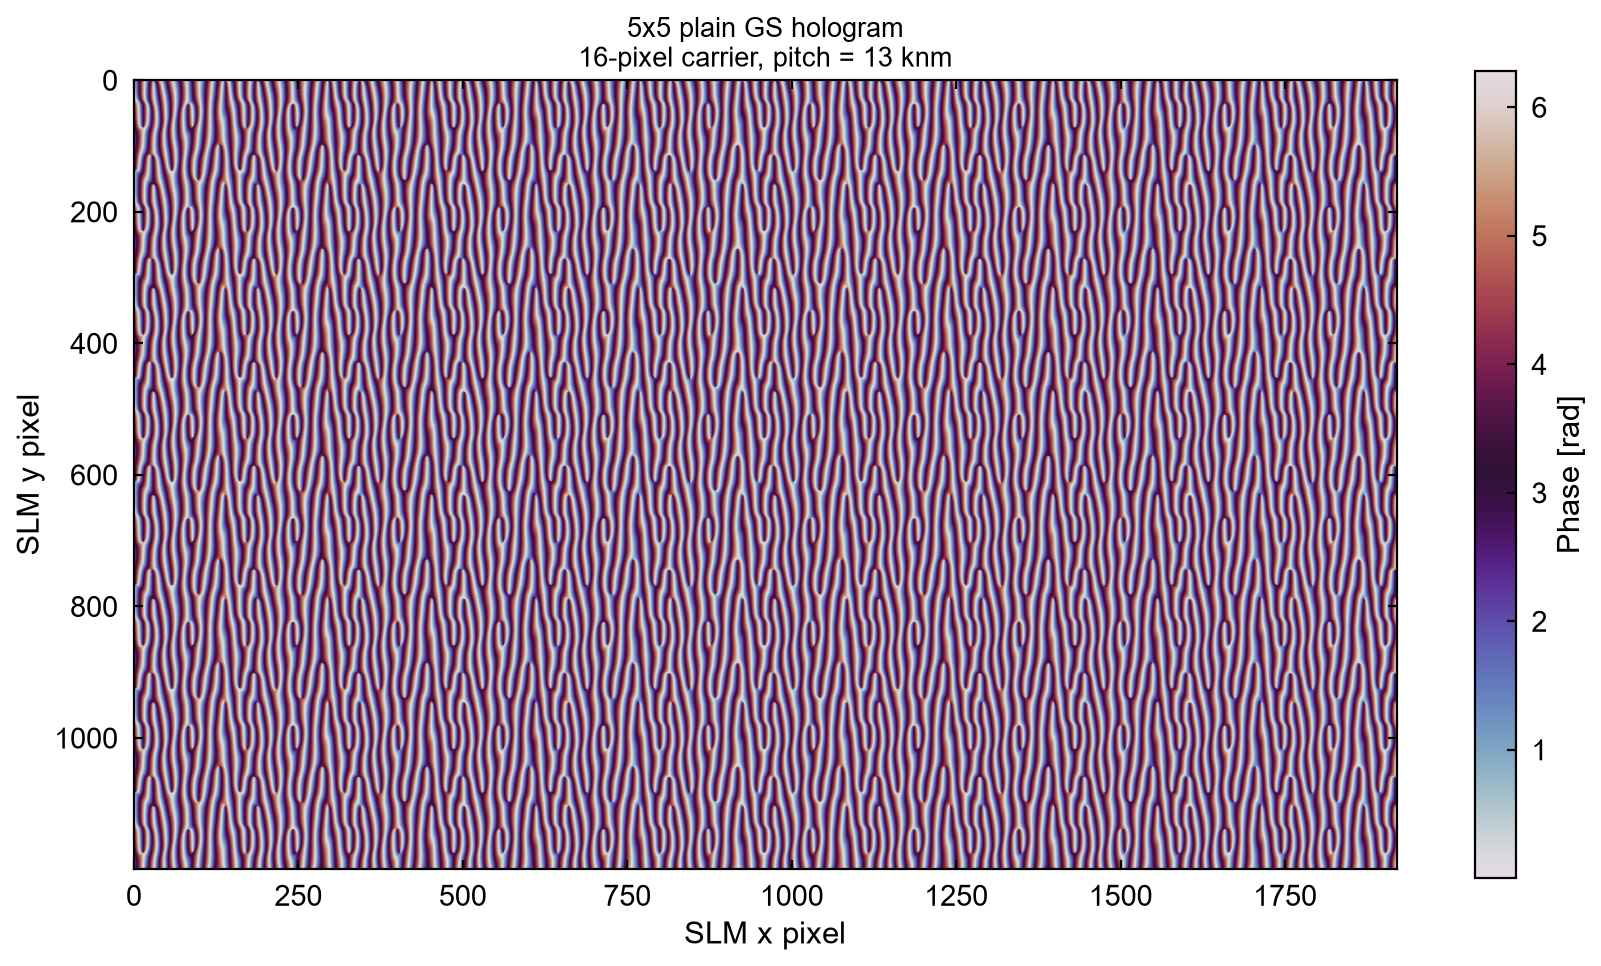


5x5 array written to SLM.
Wavefront correction explicitly DISABLED.

Generating 10 x 10 array


  0%|          | 0/30 [00:00<?, ?it/s]


Generated phase shape : (1200, 1920)
Physical SLM shape    : (1200, 1920)
Saved phase as:
  baseline_10x10_GS_phase.npy


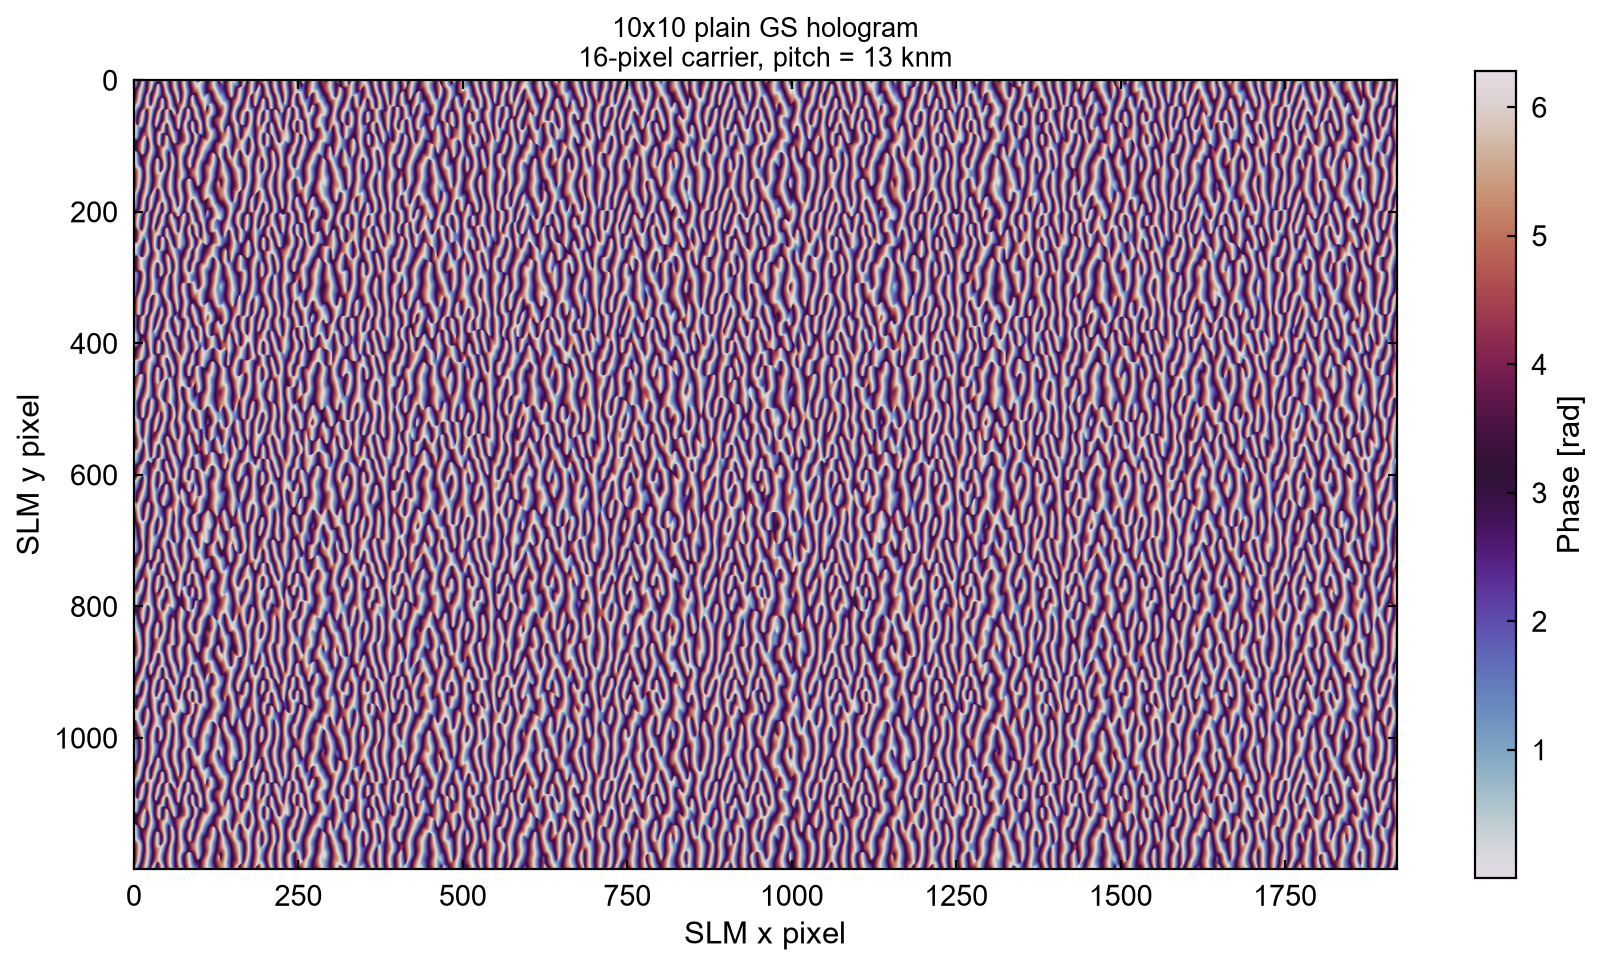


10x10 array written to SLM.
Wavefront correction explicitly DISABLED.

10x10 is now on the SLM.
Acquire and save the baseline camera images.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.holography.algorithms import SpotHologram


# ============================================================
# PARAMETERS
# ============================================================

wavelength_nm = 759.3
slm_pixel_um = 8.0

f1_mm = 250.0
f2_mm = 750.0
fobj_mm = 25.5

camera_pixel_um = 2.4

CARRIER_PERIOD_PX = 16
ARRAY_PITCH_KNM = 13

GS_ITERS = 30

# Computational Fourier grid
comp_shape = (2048, 2048)

Ny, Nx = comp_shape

cx_k = Nx / 2
cy_k = Ny / 2


# ============================================================
# FOURIER-PLANE SCALE
# ============================================================

lambda_m = wavelength_nm * 1e-9
p_slm_m = slm_pixel_um * 1e-6
f1_m = f1_mm * 1e-3

dx_fourier_m = (
    f1_m * lambda_m
    / (Nx * p_slm_m)
)

dx_fourier_um = dx_fourier_m * 1e6

print("Fourier-grid pixel size:")
print(f"  {dx_fourier_um:.3f} um")
print(f"  {dx_fourier_um / camera_pixel_um:.3f} camera pixels")


# ============================================================
# 16-PIXEL CARRIER
# ============================================================

carrier_shift_knm = Nx / CARRIER_PERIOD_PX

array_center_knm = (
    cx_k + carrier_shift_knm,
    cy_k
)

carrier_shift_um = (
    carrier_shift_knm * dx_fourier_um
)

carrier_shift_camera_px = (
    carrier_shift_um / camera_pixel_um
)

print()
print("16-pixel carrier:")
print(f"  shift in knm       = {carrier_shift_knm:.1f}")
print(f"  shift at camera    = {carrier_shift_um:.1f} um")
print(f"  shift on camera    = {carrier_shift_camera_px:.1f} pixels")


# ============================================================
# ARRAY SPACING
# ============================================================

actual_camera_spacing_um = (
    ARRAY_PITCH_KNM * dx_fourier_um
)

actual_camera_spacing_px = (
    actual_camera_spacing_um / camera_pixel_um
)

actual_atom_spacing_um = (
    actual_camera_spacing_um
    * fobj_mm
    / f2_mm
)

print()
print("Array pitch:")
print(f"  pitch in knm       = {ARRAY_PITCH_KNM}")
print(f"  camera spacing     = {actual_camera_spacing_um:.2f} um")
print(f"  camera spacing     = {actual_camera_spacing_px:.2f} px")
print(f"  atomic spacing     = {actual_atom_spacing_um:.3f} um")


# ============================================================
# FUNCTION TO GENERATE + PROJECT AN ARRAY
# ============================================================

def generate_and_project_array(N_ARRAY, save_phase=True):

    print()
    print("=" * 60)
    print(f"Generating {N_ARRAY} x {N_ARRAY} array")
    print("=" * 60)

    # --------------------------------------------------------
    # Create target array
    # --------------------------------------------------------

    holo = SpotHologram.make_rectangular_array(
        shape=comp_shape,

        array_shape=(
            N_ARRAY,
            N_ARRAY
        ),

        array_pitch=(
            ARRAY_PITCH_KNM,
            ARRAY_PITCH_KNM
        ),

        array_center=array_center_knm,

        basis="knm",

        # Actual physical SLM dimensions
        slm_shape=slm.shape,
    )


    # --------------------------------------------------------
    # Plain Gerchberg-Saxton
    #
    # This is NOT wavefront correction.
    # It only calculates the phase hologram required
    # to generate the requested spot array.
    # --------------------------------------------------------

    holo.optimize(
        method="GS",
        maxiter=GS_ITERS,
    )


    # --------------------------------------------------------
    # Get phase
    # --------------------------------------------------------

    phase = holo.get_phase()

    print()
    print("Generated phase shape :", phase.shape)
    print("Physical SLM shape    :", slm.shape)


    # --------------------------------------------------------
    # Save the actual calculated hologram
    # --------------------------------------------------------

    if save_phase:

        filename = f"baseline_{N_ARRAY}x{N_ARRAY}_GS_phase.npy"

        np.save(
            filename,
            phase
        )

        print("Saved phase as:")
        print(f"  {filename}")


    # --------------------------------------------------------
    # Plot phase
    # --------------------------------------------------------

    plt.figure(figsize=(11, 6))

    plt.imshow(
        phase,
        origin="upper",
        cmap="twilight"
    )

    plt.colorbar(
        label="Phase [rad]"
    )

    plt.title(
        f"{N_ARRAY}x{N_ARRAY} plain GS hologram\n"
        f"16-pixel carrier, pitch = {ARRAY_PITCH_KNM} knm"
    )

    plt.xlabel("SLM x pixel")
    plt.ylabel("SLM y pixel")

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # WRITE TO SLM
    #
    # IMPORTANT:
    #
    # phase_correct=False
    #
    # explicitly prevents slmsuite from applying any
    # stored wavefront correction.
    # --------------------------------------------------------

    slm.set_phase(
        phase,
        phase_correct=False,
        settle=True,
    )

    print()
    print(f"{N_ARRAY}x{N_ARRAY} array written to SLM.")
    print("Wavefront correction explicitly DISABLED.")


    return holo, phase


# ============================================================
# 1. PROJECT 5 x 5
# ============================================================

holo_5x5, phase_5x5 = generate_and_project_array(
    N_ARRAY=5
)


# ============================================================
# WAIT WHILE YOU RECORD THE CAMERA IMAGE
# ============================================================

input(
    "\n5x5 is now on the SLM.\n"
    "Acquire and save the camera images.\n"
    "Press ENTER when you are ready to switch to 10x10..."
)


# ============================================================
# 2. PROJECT 10 x 10
# ============================================================

holo_10x10, phase_10x10 = generate_and_project_array(
    N_ARRAY=10
)


print()
print("=" * 60)
print("10x10 is now on the SLM.")
print("Acquire and save the baseline camera images.")
print("=" * 60)